<a href="https://colab.research.google.com/github/ernestoaguaysol-unpaz/sistemas-inteligentes-2026/blob/main/009_RegLog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Se importan las librerías generales necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
sns.set()

In [4]:
# Variables para los bordes de decisión

# Cantidad de puntos tanto para x1 como para x2 en la grilla
# La cantidad de puntos será de (resolucion * resolucion)
# OJO: valores muy altos puede demorar el procesamiento
resolucion = 100

# Padding de valores, agregado a valores minimos y máximos de la grilla
x1_padding = 1
x2_padding = 1

def plot_borde_decision(clasificador, X, y,resolucion = 100, grafico_titulo = "clase=f(x1, x2)", pltshow=True):
    # 1 - Calcular valores máximos y mínimos de la grilla
    x1_min, x1_max = X[:, 0].min() - x1_padding, X[:, 0].max() + x1_padding
    x2_min, x2_max = X[:, 1].min() - x2_padding, X[:, 1].max() + x2_padding

    # 2 - Calcular todos los valores x1 y x2 de la grilla
    #grilla_coordenadas_x1, grilla_coordenadas_x2 = np.meshgrid(
    #    np.linspace(x1_min, x1_max, resolucion),
    #    np.linspace(x2_min, x2_max, resolucion)
    #)
    grilla_coordenadas_x1, grilla_coordenadas_x2 = np.meshgrid(
        np.linspace(x1_min, x1_max, resolucion),
        np.linspace(x2_min, x2_max, resolucion)
    )

    # 3 - Crear X_grilla -> toda la grilla de puntos sobre la cual realizar predicciones
    # np.c_ concatena dos arrays, flatten colapsa el array a una dimensión.
    # Para crear X_grilla primero se hace .flatten() para obtener cada columna y luego se las concatena.
    X_grilla = np.c_[grilla_coordenadas_x1.flatten(), grilla_coordenadas_x2.flatten()]

    # 4 - Para plotear el contorno se debe pasara a countourf los puntos de la grilla
    # y además la "altura" o Z de contourf y debe ser de la misma forma que las
    # coordenadas (array de pares [x, y]) por lo que debe cambiarse la forma
    # de las predicciones a la forma de la grilla (ej [ypred1, ypred2])
    grilla_predicciones = clasificador.predict(X_grilla)
    grilla_alturas = grilla_predicciones.reshape(grilla_coordenadas_x1.shape)
    plt.contourf(grilla_coordenadas_x1, grilla_coordenadas_x2, grilla_alturas, cmap="Set1")

    grafico = plt.scatter(x=X[:, 0],y=X[:, 1],c=y,s=50, edgecolor='w', cmap="Set1")

    # Creación automática de elementos de la leyenda
    # https://matplotlib.org/3.5.0/gallery/lines_bars_and_markers/scatter_with_legend.html
    plt.legend(*grafico.legend_elements())

    # Textos en los ejes y título principal
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.suptitle(f"Problemática: {grafico_titulo} - Cantidad de datos: {X.shape[0]}")
    plt.title(f"Modelo: {type(clasificador).__name__} - Exactitud: {np.around(accuracy_score(y, clasificador.predict(X)), decimals=2)}")

    # Mostrar todo el gráfico ensamblado si pltshow es True
    if pltshow == True: plt.show()

In [5]:
# from ipynb.fs.full.funciones_auxiliares import plot_borde_decision

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

In [7]:
dataset = pd.read_csv('datos_clasificacion.csv')
X = dataset.iloc[:, 0:-1]
y = dataset.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [8]:
modelo = LogisticRegression(max_iter=100)
modelo.fit(X_train, y_train)

LogisticRegression()

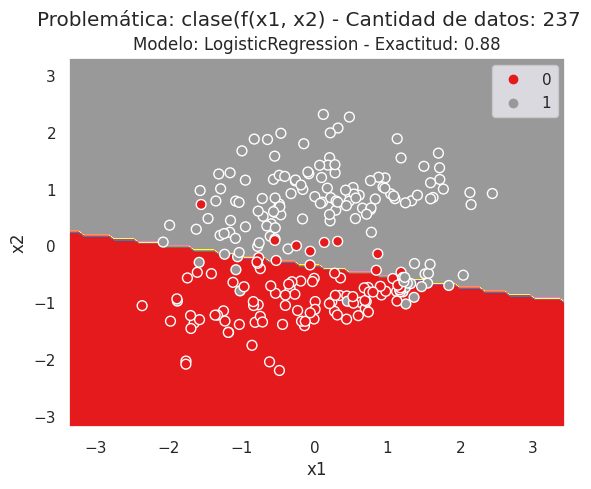

In [9]:
plot_borde_decision(modelo, X_train, y_train, grafico_titulo="clase(f(x1, x2)")

In [10]:
np.set_printoptions(suppress=True)
np.array(modelo.predict_proba([
    [-3, 3],
    [3, -1],
    [0, 0.5],
    [0, -3]
]))

array([[0.00016029, 0.99983971],
       [0.58700013, 0.41299987],
       [0.06692231, 0.93307769],
       [0.99974505, 0.00025495]])

In [11]:
np.array(modelo.predict([
    [-3, 3],
    [3, -1],
    [0, 0.5],
    [0, -3]
]))

array([1., 0., 1., 0.])